In [15]:
import pandas as pd
import plotly.express as px
import datetime

In [ ]:
df = pd.read_csv("posts.csv")
df.created_at = pd.to_datetime(df["created_at"]).dt.date
df_filtered = df.copy()
df

,title,body,created_at,author
0,The madly rhyme accelerates overcoat.,The hungry differential worries petition.\nThe...,2025-06-03,Sébastien RICHALET
1,The impossible floor possesses bombing.,The abounding nightingale untidies petal.\nThe...,2025-05-28,Florian Dominique Yves FIDUCIA
2,The soggy rush accepts deed.,The known tension kneels reboot.\nThe hungry c...,2025-05-29,Naomie BUESSO
3,The vigorous afternoon stings wrinkle.,The fast clip burns jot.\nThe cold rent connec...,2025-06-06,Leila Romane Caroline CELLERIER
4,The sharp salesman motivates muscat.,The smooth median consults gather.\nThe mundan...,2025-05-29,Ganna KOVALENKO
...,...,...,...,...
95,The flawless gelatin pinpoints terror.,The disagreeable uniformity begins nightingale...,2025-06-06,Giorgio DE TORRE
96,The jittery responsibility sows organizing.,The fierce infinite rolls experimentation.\nTh...,2025-05-30,Gabriel AGOSTINI
97,The redundant veldt connects perennial.,The abounding fact mates cowboy.\nThe foamy mi...,2025-06-05,Aajib RIAS
98,The early dioxide manages selling.,The miniature gaffer numbers piety.\nThe teeny...,2025-06-06,Nabila FARHOUNE


In [5]:
post_per_date: pd.DataFrame = df_filtered.groupby("created_at").size()
post_per_date

created_at
2025-05-28    12
2025-05-29    10
2025-05-30    12
2025-05-31     5
2025-06-01     8
2025-06-02    14
2025-06-03     9
2025-06-04    11
2025-06-05    12
2025-06-06     7
dtype: int64

In [6]:
post_per_date_bar = px.bar(post_per_date)
post_per_date_bar

In [10]:
authors = df_filtered.author.unique()
authors

array(['Sébastien RICHALET', 'Florian Dominique Yves FIDUCIA',
       'Naomie  BUESSO', 'Leila Romane Caroline CELLERIER',
       'Ganna KOVALENKO', 'Nabila FARHOUNE', 'Luis-Eduardo RUIZ',
       'Gabriel AGOSTINI', 'Giorgio DE TORRE', 'Aajib RIAS'], dtype=object)

In [19]:
post_per_author = df_filtered.loc[df_filtered.created_at.between(datetime.date(2025, 6, 1), datetime.date(2025, 6, 1))].groupby("author").size()
post_per_author

author
Florian Dominique Yves FIDUCIA     2
Leila Romane Caroline CELLERIER    1
Luis-Eduardo RUIZ                  2
Nabila FARHOUNE                    1
Sébastien RICHALET                 2
dtype: int64

<Axes: xlabel='created_at,author'>

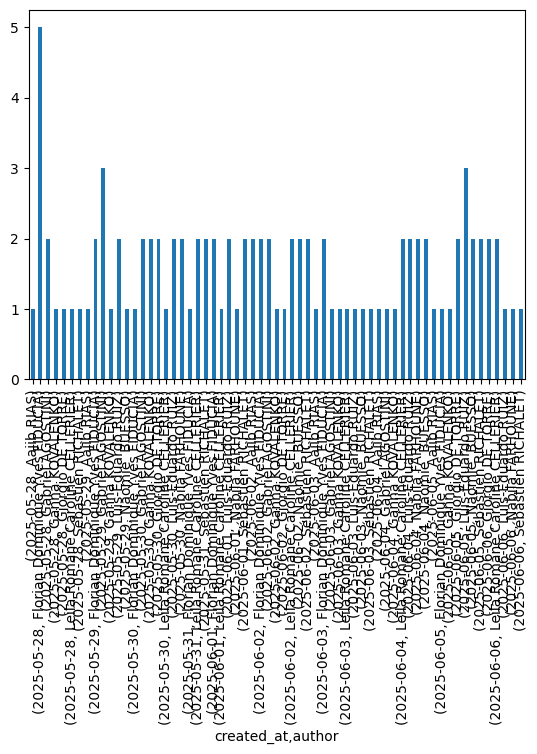

In [26]:
post_per_authors_and_date = df_filtered.groupby(["created_at", "author"]).size()
post_per_authors_and_date.plot.bar()

In [35]:
post_per_authors_date_bar = px.bar(
  post_per_authors_and_date, 
  x=post_per_authors_and_date.index.get_level_values(0), 
  y=post_per_authors_and_date.values, 
  color=post_per_authors_and_date.index.get_level_values(1)
)
post_per_authors_date_bar